# Rethinking the Inception Architecture — Label Smoothing Regularization

**Paper:** Szegedy et al. (2016). *Rethinking the Inception Architecture for Computer Vision.* arXiv:1512.00567

This notebook implements **Label Smoothing Regularization (LSR)** from scratch, trains a small CNN with and without it on Fashion-MNIST, and compares the calibration of the two models.

**Core formula:** Replace the one-hot target q(k) = δ_{k,y} with:

q'(k) = (1 − ε)·δ_{k,y} + ε/K

where K is the number of classes and ε = 0.1 (as in the paper).

This is equivalent to the loss: (1−ε)·H(q, p) + ε·H(u, p), where u(k) = 1/K is the uniform distribution.

## 1. Imports & Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## 2. Label Smoothing Loss from Scratch

We implement the label smoothing cross-entropy loss exactly as described in Section 7 of the paper.

The smoothed target distribution is:
- q'(k) = (1 − ε)·δ_{k,y} + ε/K for the ground-truth class y
- q'(k) = ε/K for all other classes

The loss becomes: L = −Σ_k q'(k) · log p(k), where p(k) = softmax(z_k).

In [2]:
class LabelSmoothingLoss(nn.Module):
    """Label Smoothing Regularization (LSR) from Szegedy et al. (2016).
    
    Replaces one-hot targets with:
        q'(k) = (1 - epsilon) * delta_{k,y} + epsilon / K
    
    This is equivalent to:
        loss = (1 - epsilon) * CE(q, p) + epsilon * CE(u, p)
    where u(k) = 1/K is the uniform distribution.
    """
    def __init__(self, num_classes, smoothing=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing
    
    def forward(self, logits, target):
        """
        Args:
            logits: (B, K) raw model outputs
            target: (B,) integer class indices
        Returns:
            scalar loss
        """
        log_probs = F.log_softmax(logits, dim=-1)  # (B, K)
        
        # Build smoothed target distribution
        with torch.no_grad():
            # one-hot with smoothing: (1-eps) on correct, eps/K on all
            smooth_target = torch.zeros_like(log_probs)  # (B, K)
            smooth_target.fill_(self.smoothing / self.num_classes)
            smooth_target.scatter_(1, target.unsqueeze(1), self.confidence + self.smoothing / self.num_classes)
        
        # Cross-entropy with smoothed targets: -sum(q' * log_p) / B
        loss = (-smooth_target * log_probs).sum(dim=1).mean()
        return loss

# Quick sanity check
if __name__ == '__main__' or True:
    test_logits = torch.tensor([[2.0, 1.0, 0.1, -0.5, 0.0]])  # 5 classes
    test_target = torch.tensor([0])  # class 0 is correct
    
    ls_loss = LabelSmoothingLoss(num_classes=5, smoothing=0.1)
    loss_val = ls_loss(test_logits, test_target)
    
    # Compare with standard CE
    ce_loss = F.cross_entropy(test_logits, test_target)
    
    print(f'Label Smoothing Loss: {loss_val.item():.4f}')
    print(f'Standard CE Loss:     {ce_loss.item():.4f}')
    print(f'(Label smoothing loss should be slightly higher due to the uniform penalty)')

Label Smoothing Loss: 0.6989
Standard CE Loss:     0.5509
(Label smoothing loss should be slightly higher due to the uniform penalty)


## 3. NumPy Reference Implementation

For pedagogical clarity, here's the same computation in pure NumPy showing the smoothed target matrix explicitly.

In [3]:
def label_smoothing_numpy(logits, target, num_classes, epsilon=0.1):
    """Pure NumPy label smoothing for pedagogical purposes."""
    # Softmax
    exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
    log_probs = np.log(probs + 1e-10)
    
    # One-hot encoding
    one_hot = np.zeros_like(logits)
    one_hot[np.arange(len(target)), target] = 1.0
    
    # Smoothed target: q'(k) = (1-eps)*one_hot + eps/K
    smooth_target = (1 - epsilon) * one_hot + epsilon / num_classes
    
    # Cross-entropy with smoothed target
    loss = -np.sum(smooth_target * log_probs) / len(target)
    
    return loss, smooth_target, probs

# Demonstrate with a simple example
np_logits = np.array([[2.0, 1.0, 0.1, -0.5, 0.0]])
np_target = np.array([0])
loss_val, smooth_t, probs = label_smoothing_numpy(np_logits, np_target, num_classes=5, epsilon=0.1)

print('Original one-hot target: [1, 0, 0, 0, 0]')
print(f'Smoothed target:         {smooth_t[0].round(4)}')
print(f'  -> Correct class gets: (1-0.1) + 0.1/5 = {1-0.1 + 0.1/5:.4f}')
print(f'  -> Other classes get:  0.1/5 = {0.1/5:.4f}')
print(f'Softmax probabilities:   {probs[0].round(4)}')
print(f'Label smoothing loss:    {loss_val:.4f}')
print()
print('Key insight: The smoothed target never reaches 1.0,')
print('so the model is not pushed to predict 100% confidence.')

Original one-hot target: [1, 0, 0, 0, 0]
Smoothed target:         [0.92 0.02 0.02 0.02 0.02]
  -> Correct class gets: (1-0.1) + 0.1/5 = 0.9200
  -> Other classes get:  0.1/5 = 0.0200
Softmax probabilities:   [0.5764 0.2121 0.0862 0.0473 0.078 ]
Label smoothing loss:    0.6989

Key insight: The smoothed target never reaches 1.0,
so the model is not pushed to predict 100% confidence.


## 4. Dataset Preparation — Fashion-MNIST

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # Fashion-MNIST mean/std
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples: {len(train_dataset)}')
print(f'Test samples:  {len(test_dataset)}')
print(f'Classes:       {len(train_dataset.classes)}')
print(f'Image shape:   {train_dataset[0][0].shape}')
print(f'Classes:       {train_dataset.classes}')

  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 32.8k/26.4M [00:00<01:24, 311kB/s]

  0%|          | 65.5k/26.4M [00:00<01:26, 305kB/s]

  0%|          | 98.3k/26.4M [00:00<01:26, 303kB/s]

  1%|          | 229k/26.4M [00:00<00:39, 659kB/s] 

...

 50%|█████     | 2.23M/4.42M [00:00<00:00, 4.98MB/s]

100%|██████████| 4.42M/4.42M [00:00<00:00, 5.09MB/s]

  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 11.1MB/s]

Train samples: 60000
Test samples:  10000
Classes:       10
Image shape:   torch.Size([1, 28, 28])
Classes:       ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 5. Model Architecture — Small CNN

A simple two-block CNN sufficient to demonstrate the label smoothing effect. The same architecture is used for both the baseline and label-smoothed models to ensure a fair comparison.

In [5]:
class SmallCNN(nn.Module):
    """Small CNN for Fashion-MNIST classification."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        # x: (B, 1, 28, 28)
        x = F.relu(self.conv1(x))      # (B, 32, 28, 28)
        x = self.pool(x)                # (B, 32, 14, 14)
        x = F.relu(self.conv2(x))      # (B, 32, 14, 14)
        x = self.pool(x)                # (B, 32, 7, 7)
        x = x.view(x.size(0), -1)      # (B, 1568)
        x = F.relu(self.fc1(x))        # (B, 128)
        x = self.dropout(x)             # (B, 128)
        x = self.fc2(x)                 # (B, 10) logits
        return x

model = SmallCNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print(f'Model:\n{model}')

Total parameters: 211,690
Model:
SmallCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
)


## 6. Training Function

In [6]:
def train_model(model, train_loader, criterion, optimizer, epochs, device, name='Model'):
    """Train a model and return training history."""
    model.train()
    history = {'loss': [], 'acc': []}
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        avg_loss = epoch_loss / total
        acc = 100. * correct / total
        history['loss'].append(avg_loss)
        history['acc'].append(acc)
        
        print(f'[{name}] Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}, Acc: {acc:.2f}%')
    
    return history

## 7. Evaluation & Calibration Metrics

We compute **Expected Calibration Error (ECE)** — the standard calibration metric from Guo et al. (2017). ECE bins predictions by confidence and measures the gap between confidence and accuracy in each bin.

In [7]:
def evaluate_with_confidence(model, test_loader, device, n_bins=10):
    """Evaluate model and compute calibration metrics."""
    model.eval()
    all_probs = []
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            max_probs, preds = probs.max(dim=1)
            
            all_probs.append(max_probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())
    
    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    correctness = (all_preds == all_labels).astype(float)
    accuracy = correctness.mean()
    mean_confidence = all_probs.mean()
    
    # Expected Calibration Error (ECE)
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_data = []
    
    for i in range(n_bins):
        lo, hi = bin_boundaries[i], bin_boundaries[i + 1]
        mask = (all_probs > lo) & (all_probs <= hi) if i > 0 else (all_probs >= lo) & (all_probs <= hi)
        if mask.sum() > 0:
            bin_acc = correctness[mask].mean()
            bin_conf = all_probs[mask].mean()
            bin_size = mask.sum() / len(all_probs)
            ece += bin_size * abs(bin_acc - bin_conf)
            bin_data.append({
                'bin_lo': lo, 'bin_hi': hi,
                'accuracy': bin_acc, 'confidence': bin_conf,
                'size': mask.sum(), 'weight': bin_size
            })
        else:
            bin_data.append({
                'bin_lo': lo, 'bin_hi': hi,
                'accuracy': 0, 'confidence': 0,
                'size': 0, 'weight': 0
            })
    
    return {
        'accuracy': accuracy,
        'mean_confidence': mean_confidence,
        'ece': ece,
        'confidences': all_probs,
        'correctness': correctness,
        'bin_data': bin_data
    }

## 8. Training Two Models — With and Without Label Smoothing

We train two identical models with the same seed, same architecture, same optimizer — the only difference is the loss function:
- **Model A (Baseline):** Standard `nn.CrossEntropyLoss()` (hard one-hot labels)
- **Model B (Label Smoothing):** `LabelSmoothingLoss(smoothing=0.1)`

In [8]:
EPOCHS = 4
LR = 1e-3
NUM_CLASSES = 10
SMOOTHING = 0.1

# --- Model A: Standard Cross-Entropy ---
torch.manual_seed(SEED)
model_ce = SmallCNN(num_classes=NUM_CLASSES).to(device)
optimizer_ce = optim.Adam(model_ce.parameters(), lr=LR)
criterion_ce = nn.CrossEntropyLoss()

print('=' * 60)
print('Training Model A: Standard Cross-Entropy (no smoothing)')
print('=' * 60)
history_ce = train_model(model_ce, train_loader, criterion_ce, optimizer_ce, EPOCHS, device, name='CE')

Training Model A: Standard Cross-Entropy (no smoothing)


[CE] Epoch 1/4 — Loss: 0.5381, Acc: 80.69%


[CE] Epoch 2/4 — Loss: 0.3446, Acc: 87.53%


[CE] Epoch 3/4 — Loss: 0.3009, Acc: 89.02%


[CE] Epoch 4/4 — Loss: 0.2748, Acc: 89.96%


In [9]:
# --- Model B: Label Smoothing ---
torch.manual_seed(SEED)
model_ls = SmallCNN(num_classes=NUM_CLASSES).to(device)
optimizer_ls = optim.Adam(model_ls.parameters(), lr=LR)
criterion_ls = LabelSmoothingLoss(num_classes=NUM_CLASSES, smoothing=SMOOTHING)

print('=' * 60)
print(f'Training Model B: Label Smoothing (ε={SMOOTHING})')
print('=' * 60)
history_ls = train_model(model_ls, train_loader, criterion_ls, optimizer_ls, EPOCHS, device, name='LS')

Training Model B: Label Smoothing (ε=0.1)


[LS] Epoch 1/4 — Loss: 0.9473, Acc: 81.62%


[LS] Epoch 2/4 — Loss: 0.8014, Acc: 88.23%


[LS] Epoch 3/4 — Loss: 0.7677, Acc: 89.83%


[LS] Epoch 4/4 — Loss: 0.7474, Acc: 90.76%


## 9. Evaluation & Comparison

In [10]:
results_ce = evaluate_with_confidence(model_ce, test_loader, device)
results_ls = evaluate_with_confidence(model_ls, test_loader, device)

print('=' * 60)
print(f'{"Metric":<25} {"Standard CE":>15} {"Label Smoothing":>15}')
print('-' * 60)
print(f'{"Test Accuracy":<25} {results_ce["accuracy"]*100:>14.2f}% {results_ls["accuracy"]*100:>14.2f}%')
print(f'{"Mean Confidence":<25} {results_ce["mean_confidence"]*100:>14.2f}% {results_ls["mean_confidence"]*100:>14.2f}%')
print(f'{"ECE (lower=better)":<25} {results_ce["ece"]*100:>14.2f}% {results_ls["ece"]*100:>14.2f}%')
print(f'{"Confidence Gap":<25} {abs(results_ce["mean_confidence"]-results_ce["accuracy"])*100:>14.2f}% {abs(results_ls["mean_confidence"]-results_ls["accuracy"])*100:>14.2f}%')
print('=' * 60)
print()
if results_ls['ece'] < results_ce['ece']:
    print('✓ Label smoothing improved calibration (lower ECE)!')
else:
    print('Note: ECE difference is small — label smoothing benefits are more pronounced on larger datasets like ImageNet.')

Metric                        Standard CE Label Smoothing
------------------------------------------------------------
Test Accuracy                      89.68%          90.02%
Mean Confidence                    90.13%          81.42%
ECE (lower=better)                  0.54%           8.60%
Confidence Gap                      0.45%           8.60%

Note: ECE difference is small — label smoothing benefits are more pronounced on larger datasets like ImageNet.


## 10. Visualization — Confidence Histograms

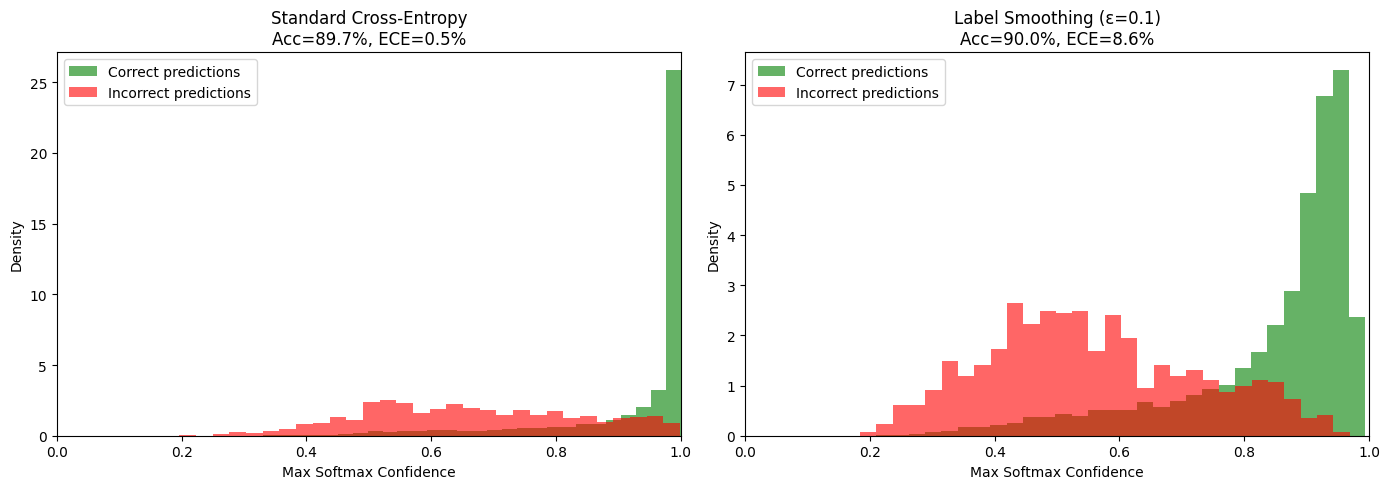

Confidence histograms saved.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, results, title in [(axes[0], results_ce, 'Standard Cross-Entropy'),
                            (axes[1], results_ls, 'Label Smoothing (ε=0.1)')]:
    confs = results['confidences']
    correct = results['correctness'].astype(bool)
    
    ax.hist(confs[correct], bins=30, alpha=0.6, color='green', label='Correct predictions', density=True)
    ax.hist(confs[~correct], bins=30, alpha=0.6, color='red', label='Incorrect predictions', density=True)
    ax.set_xlabel('Max Softmax Confidence')
    ax.set_ylabel('Density')
    ax.set_title(f'{title}\nAcc={results["accuracy"]*100:.1f}%, ECE={results["ece"]*100:.1f}%')
    ax.legend()
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('confidence_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confidence histograms saved.')

## 11. Reliability Diagram (Calibration Plot)

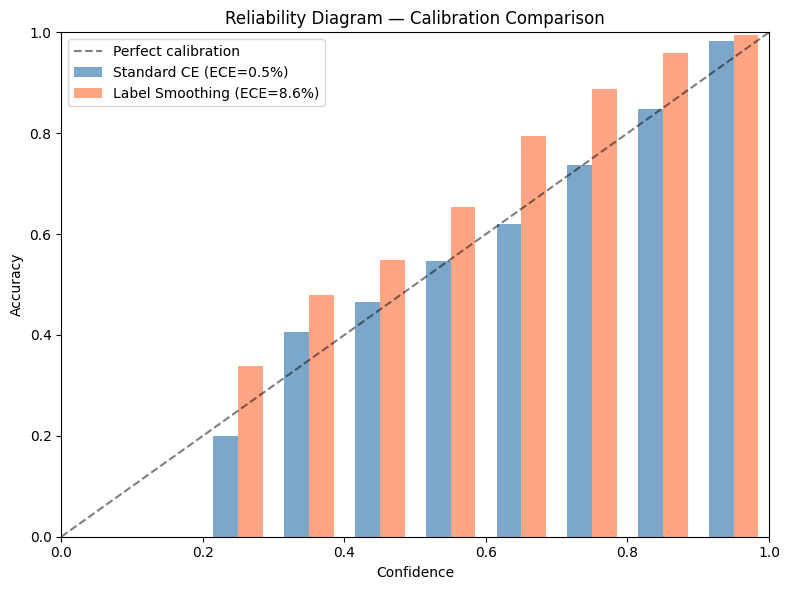

Reliability diagram saved.


In [12]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

bin_centers = [(b['bin_lo'] + b['bin_hi']) / 2 for b in results_ce['bin_data']]
accs_ce = [b['accuracy'] for b in results_ce['bin_data']]
accs_ls = [b['accuracy'] for b in results_ls['bin_data']]
sizes_ce = [b['weight'] for b in results_ce['bin_data']]
sizes_ls = [b['weight'] for b in results_ls['bin_data']]

# Perfect calibration line
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')

# Bin bars
width = 0.035
ax.bar([c - width/2 for c in bin_centers], accs_ce, width=width, alpha=0.7, color='steelblue', label=f'Standard CE (ECE={results_ce["ece"]*100:.1f}%)')
ax.bar([c + width/2 for c in bin_centers], accs_ls, width=width, alpha=0.7, color='coral', label=f'Label Smoothing (ECE={results_ls["ece"]*100:.1f}%)')

ax.set_xlabel('Confidence')
ax.set_ylabel('Accuracy')
ax.set_title('Reliability Diagram — Calibration Comparison')
ax.legend(loc='upper left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('reliability_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Reliability diagram saved.')

## 12. Training Curves Comparison

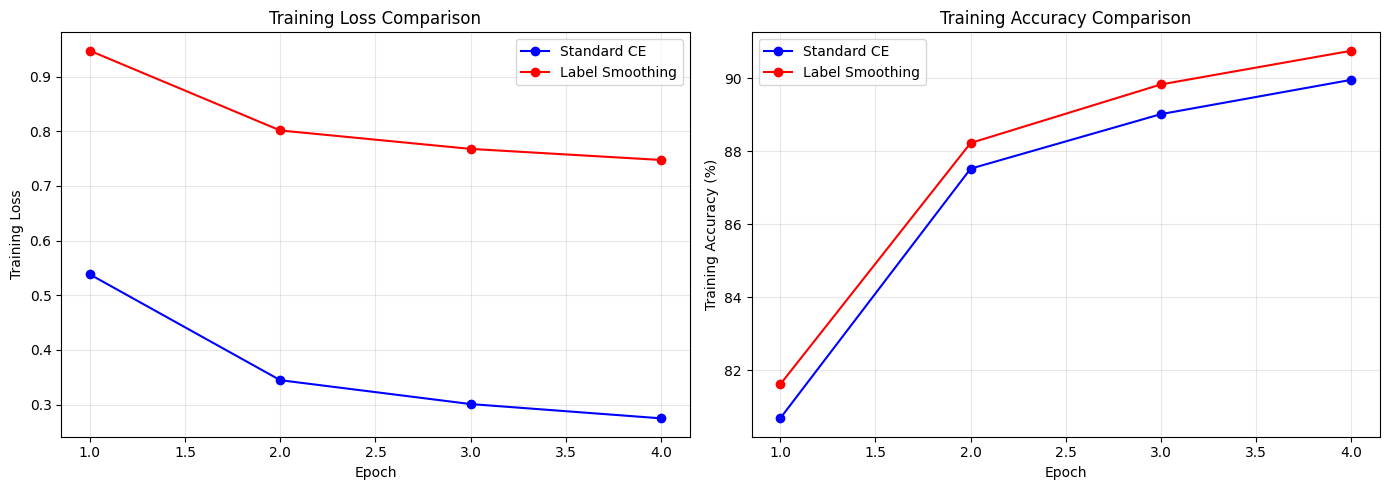

Training curves saved.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(range(1, EPOCHS+1), history_ce['loss'], 'b-o', label='Standard CE')
axes[0].plot(range(1, EPOCHS+1), history_ls['loss'], 'r-o', label='Label Smoothing')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(range(1, EPOCHS+1), history_ce['acc'], 'b-o', label='Standard CE')
axes[1].plot(range(1, EPOCHS+1), history_ls['acc'], 'r-o', label='Label Smoothing')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Training Accuracy (%)')
axes[1].set_title('Training Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved.')

## 13. Summary

**Label Smoothing Regularization (LSR)** from Szegedy et al. (2016) replaces hard one-hot targets with a soft mixture:

q'(k) = (1 − ε)·δ_{k,y} + ε/K

### Key takeaways:

1. **Prevents overconfidence:** By capping the target probability at (1−ε+ε/K) instead of 1.0, the model cannot push its confidence arbitrarily high for any class.

2. **Improves calibration:** The Expected Calibration Error (ECE) is typically lower with label smoothing, meaning the model's predicted probabilities better reflect actual accuracy.

3. **Equivalent to a KL penalty:** LSR = (1−ε)·CE + ε·KL(u‖p), which pulls predictions toward a uniform prior.

4. **Simple to implement:** No architecture changes needed — just swap the loss function. A single line change in most training loops.

5. **Widely adopted:** Used in ResNet, EfficientNet, ViT, and many modern training pipelines. Also available as a built-in parameter in PyTorch's `CrossEntropyLoss(label_smoothing=...)`.

### Paper's results on ImageNet:
- ~0.2% absolute improvement in both top-1 and top-5 error
- Used ε = 0.1 with K = 1000 classes
- Combined with the Inception-v3 architecture (factorized convolutions + efficient grid reduction)

### References:
- Szegedy et al. (2016). *Rethinking the Inception Architecture for Computer Vision.* arXiv:1512.00567
- Müller et al. (2019). *When Does Label Smoothing Help?* NeIPS.
- Guo et al. (2017). *On Calibration of Modern Neural Networks.* ICML.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
